In [ ]:
pip install transformers datasets torch scikit-learn

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
label_map = {
    "No": 0,
    "Yes": 1,
    "Probably": 2
}

In [ ]:
class ClaimDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
def train_xlm(train_path, test_path, name):
    print(f"\n===== {name} ===telek==")

    import pandas as pd
    import torch
    import numpy as np


    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)


    label_map = {
        "No": 0,
        "Yes": 1,
        "Probably": 2
    }


    train_df["label"] = train_df[name.lower()]

    test_df["label"] = test_df["majority_label"].map(label_map)


    initial_train_rows = len(train_df)
    initial_test_rows = len(test_df)

    train_df.dropna(subset=['label'], inplace=True)
    test_df.dropna(subset=['label'], inplace=True)

    if len(train_df) < initial_train_rows:
        print(f"Dropped {initial_train_rows - len(train_df)} rows from training data due to missing or unmappable labels.")
    if len(test_df) < initial_test_rows:
        print(f"Dropped {initial_test_rows - len(test_df)} rows from test data due to missing or unmappable labels.")


    if train_df.empty:
        print(f"Warning: Training data for {name} is empty after label mapping and dropping NaNs. Skipping training.")
        return None, None, None
    if test_df.empty:
        print(f"Warning: Test data for {name} is empty after label mapping and dropping NaNs. Skipping training.")
        return None, None, None

    train_df['text'] = train_df['text'].astype(str)
    test_df['text'] = test_df['text'].astype(str)


    test_df["label"] = test_df["label"].astype(int)

    train_dataset = ClaimDataset(train_df["text"], train_df["label"])
    test_dataset = ClaimDataset(test_df["text"], test_df["label"])

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3
    )

    training_args = TrainingArguments(
        output_dir=f"./results_{name}",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        logging_dir='./logs'
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(axis=1)
        acc = accuracy_score(labels, preds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted"
        )
        return {"accuracy": acc, "f1": f1}

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    predictions = trainer.predict(test_dataset)

    probs = torch.nn.functional.softmax(
        torch.tensor(predictions.predictions), dim=1
    ).numpy()

    threshold = 0.6

    y_pred = []
    for p in probs:
        if np.max(p) < threshold:
            y_pred.append(2)
        else:
            y_pred.append(np.argmax(p))

    y_pred = np.array(y_pred)

    return test_df["label"], y_pred, probs

In [ ]:
y1, p1, prob1 = train_xlm("data/train_annotator1.csv", "data/test_annotator1.csv", "Annotator1")
y2, p2, prob2 = train_xlm("data/train_annotator2.csv", "data/test_annotator2.csv", "Annotator2")
y3, p3, prob3 = train_xlm("data/train_annotator3.csv", "data/test_annotator3.csv", "Annotator3")


===== Annotator1 ===telek==
Dropped 91 rows from test data due to missing or unmappable labels.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


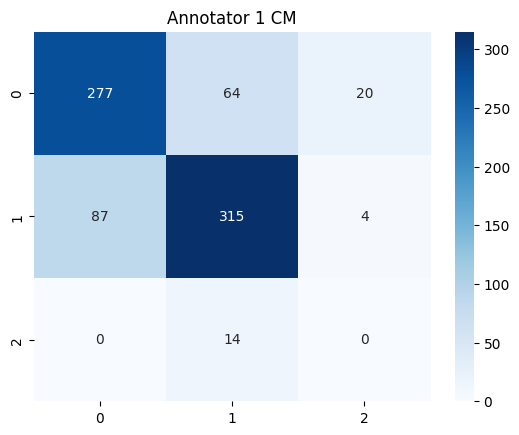

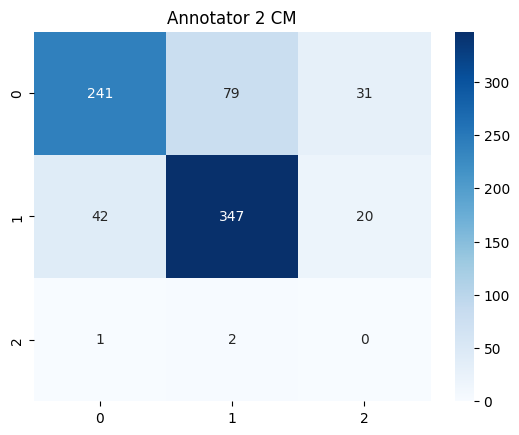

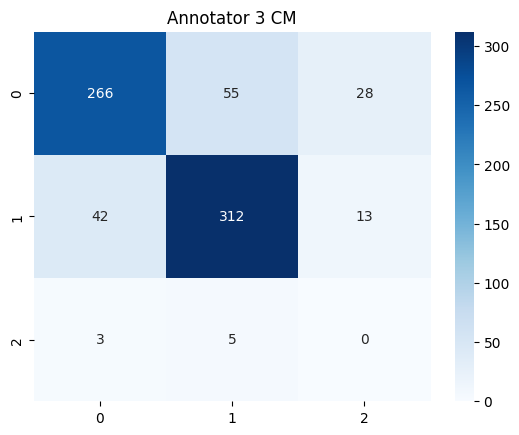

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.show()

if y1 is not None and p1 is not None:
    plot_cm(y1, p1, "Annotator 1 CM")
else:
    print("Skipping Confusion Matrix for Annotator 1: Data is None.")

if y2 is not None and p2 is not None:
    plot_cm(y2, p2, "Annotator 2 CM")
else:
    print("Skipping Confusion Matrix for Annotator 2: Data is None.")

if y3 is not None and p3 is not None:
    plot_cm(y3, p3, "Annotator 3 CM")
else:
    print("Skipping Confusion Matrix for Annotator 3: Data is None.")

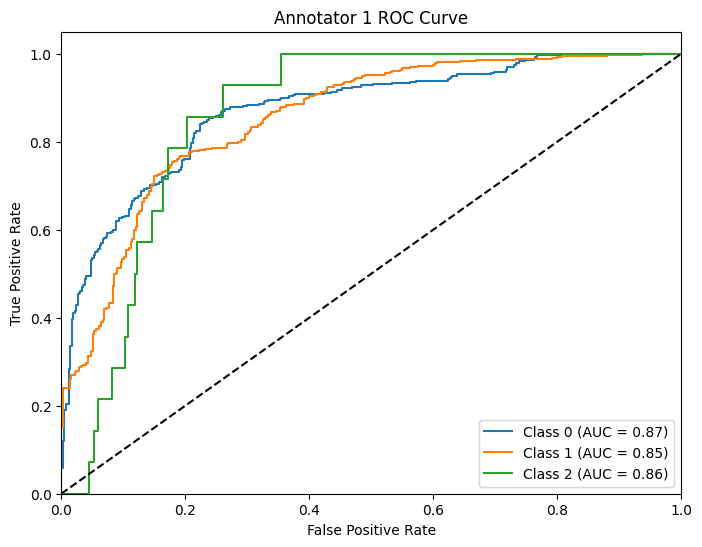

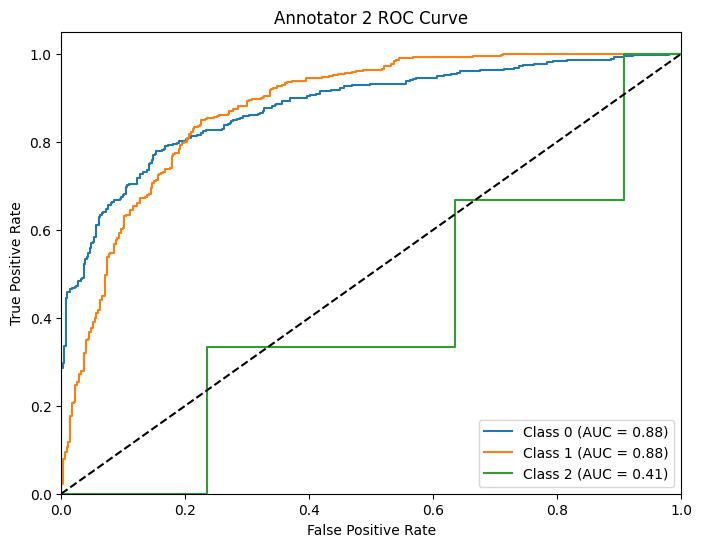

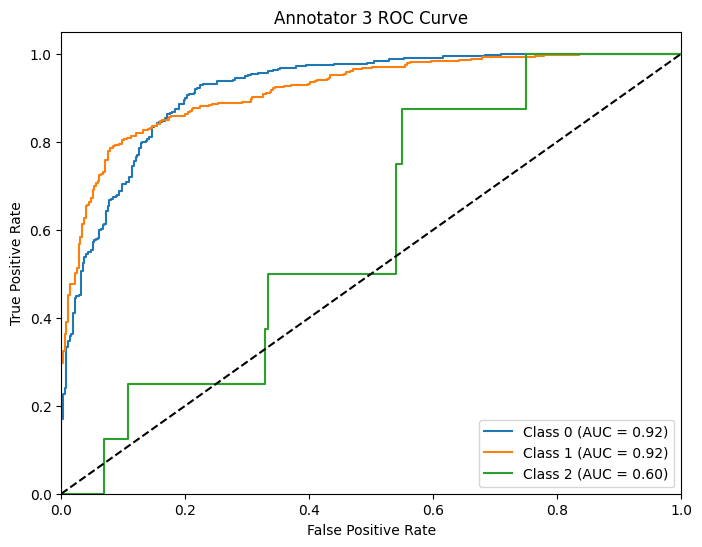

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc(y_true, y_prob, title):

    y_bin = label_binarize(y_true, classes=[0, 1, 2])

    plt.figure(figsize=(8, 6))
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()


if y1 is not None and prob1 is not None:
    plot_roc(y1, prob1, "Annotator 1 ROC Curve")
else:
    print("Skipping ROC Curve for Annotator 1: Data is None.")

if y2 is not None and prob2 is not None:
    plot_roc(y2, prob2, "Annotator 2 ROC Curve")
else:
    print("Skipping ROC Curve for Annotator 2: Data is None.")

if y3 is not None and prob3 is not None:
    plot_roc(y3, prob3, "Annotator 3 ROC Curve")
else:
    print("Skipping ROC Curve for Annotator 3: Data is None.")

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

def evaluate_metrics(y_true, y_pred, y_prob, name):
    if y_true is None or y_pred is None or y_prob is None:
        print(f"Skipping metrics for {name}: Data is None.")
        return


    try:

        from sklearn.preprocessing import label_binarize
        y_true_binarized = label_binarize(y_true, classes=[0, 1, 2])
        roc_auc = roc_auc_score(y_true_binarized, y_prob, average='macro', multi_class='ovo')
        print(f"{name} ROC AUC Score (ovo, macro-average): {roc_auc:.4f}")
    except ValueError as e:
        print(f"Could not calculate ROC AUC for {name}: {e}")


    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    print(f"{name} Precision (weighted): {precision:.4f}")
    print(f"{name} Recall (weighted): {recall:.4f}")
    print(f"{name} F1-score (weighted): {f1:.4f}")
    print("\n")


evaluate_metrics(y1, p1, prob1, "Annotator 1")
evaluate_metrics(y2, p2, prob2, "Annotator 2")
evaluate_metrics(y3, p3, prob3, "Annotator 3")

Annotator 1 ROC AUC Score (ovo, macro-average): 0.8611
Annotator 1 Precision (weighted): 0.7684
Annotator 1 Recall (weighted): 0.7580
Annotator 1 F1-score (weighted): 0.7631


Annotator 2 ROC AUC Score (ovo, macro-average): 0.7212
Annotator 2 Precision (weighted): 0.8250
Annotator 2 Recall (weighted): 0.7706
Annotator 2 F1-score (weighted): 0.7936


Annotator 3 ROC AUC Score (ovo, macro-average): 0.8117
Annotator 3 Precision (weighted): 0.8374
Annotator 3 Recall (weighted): 0.7983
Annotator 3 F1-score (weighted): 0.8166


